# Outliers — spotting the values that distort everything, and deciding what to do about them

01 Core Python · 02 Pandas · **▶ 03 Cleaning** · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`03_Data_Cleaning/05_outlier_detection_and_treatment.ipynb`

---

### In one paragraph (no jargon)

An outlier is a value far away from the rest. It might be a typo (a data-entry slip putting an age of 600), or it might be the most important record in the file (the fraud, the whale customer, the machine about to fail). That distinction is the whole subject: **detection is statistics, treatment is judgement.** One extreme value can drag a mean, inflate a standard deviation and flip the sign of a correlation, so you cannot ignore them — but deleting them because they're inconvenient is data manipulation.

### After this notebook you can

- Detect outliers four ways: visually, by z-score, by modified z-score, and by IQR
- Detect multivariate outliers — rows that are odd in combination rather than in one column
- Apply the four treatments: remove, cap, transform, or impute
- Choose a treatment and defend it in one sentence


### What's inside

1. Setup and first look
2. PART A — Detection: visual, z-score, modified z-score, IQR, model-based
3. PART B — Treatment: removal, capping, transformation, imputation
4. Every treatment compared
5. Decision guide
6. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_advertisement():
    """Exact copy of advertisement.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Unnamed: 0,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,14.2,1.0,4.8
10,199.8,12.5,21.2,10.6
11,66.1,5.8,24.2,8.6
12,214.7,24.0,4.0,17.4
13,23.8,35.1,65.9,9.2
14,97.5,7.6,7.2,9.7
15,204.1,32.9,46.0,19.0
16,195.4,47.7,52.9,22.4
17,67.8,36.6,16.0,12.5
18,281.4,39.6,55.8,24.4
19,69.2,20.5,18.3,11.3
20,147.3,23.9,19.1,14.6
21,1200.0,27.7,53.4,18.0
22,237.4,5.1,23.5,12.5
23,13.2,15.9,49.6,5.6
24,228.3,16.9,26.2,15.5
25,62.3,12.6,18.3,9.7
26,0.0,3.5,19.5,12.0
27,142.9,29.3,12.6,15.0
28,240.1,16.7,22.9,15.9
29,248.8,27.1,22.9,18.9
30,70.6,16.0,200.0,10.5
31,292.9,28.3,43.2,21.4
32,112.9,17.4,38.6,11.9
33,97.2,16.9,30.0,9.6
34,265.6,20.0,0.3,17.4
35,95.7,15.0,7.4,9.5
36,290.7,12.5,8.5,12.8
37,266.9,21.0,5.0,25.4
38,74.7,49.4,45.7,14.7
39,43.1,26.7,85.0,10.1
40,228.0,37.7,32.0,21.5
41,202.5,22.3,31.6,16.6
42,177.0,33.4,38.7,17.1
43,293.6,27.7,1.8,20.7
44,206.9,8.4,26.4,12.9
45,25.1,25.7,43.3,8.5
46,175.1,22.5,31.5,14.9
47,89.7,9.9,35.7,10.6
48,239.9,41.5,18.5,23.2
49,227.2,15.8,49.9,14.8
50,66.9,11.7,36.8,9.7
51,199.8,13.5,34.6,11.4
52,100.4,9.6,85.0,10.7
53,216.4,41.7,39.6,22.6
54,182.6,46.2,58.7,21.2
55,262.7,28.8,15.9,20.2
56,198.9,49.4,60.0,23.7
57,7.3,28.1,41.4,5.5
58,136.2,19.2,16.6,13.2
59,,49.6,0.0,23.8
60,210.7,29.5,9.3,18.4
61,53.5,14.3,21.4,8.1
62,261.3,42.7,54.7,24.2
63,239.3,15.5,27.3,15.7
64,102.7,29.6,8.4,14.0
65,131.1,42.8,28.9,18.0
66,69.0,9.3,0.9,9.3
67,31.5,24.6,2.2,9.5
68,139.3,14.5,10.2,13.4
69,237.4,27.5,11.0,18.9
70,216.8,43.9,27.2,22.3
71,199.1,30.6,38.7,18.3
72,109.8,14.3,31.7,12.4
73,26.8,33.0,98.0,8.8
74,129.4,5.7,31.3,11.0
75,213.4,24.6,13.1,17.0
76,16.9,43.7,89.4,8.7
77,27.5,11.6,20.7,6.9
78,120.5,28.5,14.2,14.2
79,5.4,29.9,9.4,5.3
80,1125.0,7.7,23.1,11.0
81,76.4,26.7,22.3,11.8
82,852.0,4.1,36.9,12.3
83,75.3,20.3,32.5,11.3
84,68.4,44.5,35.6,13.6
85,213.5,43.0,175.0,21.7
86,193.2,18.4,65.7,15.2
87,76.3,27.5,16.0,12.0
88,110.7,40.6,63.2,16.0
89,88.3,25.5,73.4,12.9
90,109.8,47.8,51.4,16.7
91,134.3,4.9,9.3,11.2
92,28.6,12.5,33.0,7.3
93,217.7,33.5,59.0,19.4
94,250.9,36.5,72.3,22.2
95,107.4,14.0,10.9,11.5
96,163.3,31.6,52.9,16.9
97,197.6,3.5,5.9,11.7
98,184.9,21.0,22.0,15.5
99,289.7,42.3,51.2,25.4
100,135.2,41.7,45.9,17.2
101,222.4,4.3,49.8,11.7
102,296.4,36.3,100.9,23.8
103,280.2,10.1,21.4,14.8
104,187.9,17.2,17.9,14.7
105,238.2,34.3,5.3,20.7
106,137.9,46.4,59.0,19.2
107,25.0,11.0,29.7,7.2
108,90.4,12.5,23.2,8.7
109,13.1,13.5,25.6,5.3
110,255.4,26.9,5.5,19.8
111,225.8,8.2,56.5,13.4
112,241.7,38.0,23.2,21.8
113,175.7,15.4,2.4,14.1
114,209.6,20.6,10.7,15.9
115,78.2,46.8,34.5,14.6
116,75.1,35.0,52.7,12.6
117,139.2,14.3,25.6,12.2
118,76.4,10.8,14.8,9.4
119,125.7,36.9,79.2,15.9
120,19.4,16.0,22.3,6.6
121,141.3,26.8,146.0,15.5
122,18.8,21.7,50.4,7.0
123,224.0,12.5,15.6,11.6
124,123.1,34.6,12.4,15.2
125,229.5,32.3,74.2,19.7
126,87.2,11.8,25.9,10.6
127,7.8,38.9,50.6,6666.0
128,80.2,25.0,0.0,8.8
129,220.3,49.0,3.2,24.7
130,59.6,12.0,43.1,9.7
131,0.7,39.6,8.7,1.6
132,265.2,15.0,43.0,12.7
133,8.4,27.2,2.1,5.7
134,219.8,33.5,45.1,19.6
135,36.9,38.6,65.6,10.8
136,48.3,47.0,8.5,11.6
137,25.6,39.0,9.3,9.5
138,273.7,28.9,59.7,20.8
139,43.0,25.9,20.5,9.6
140,925.0,43.9,1.7,20.7
141,73.4,17.0,12.9,10.9
142,193.7,35.4,75.6,19.2
143,220.5,33.2,37.9,20.1
144,104.6,5.7,34.4,10.4
145,96.2,14.8,38.9,11.4
146,140.3,15.2,9.0,10.3
147,240.1,7.3,8.7,13.2
148,243.2,49.0,44.3,25.4
149,38.0,40.3,11.9,10.9
150,44.7,25.8,20.6,10.1
151,280.7,13.9,37.0,16.1
152,,8.4,48.7,11.6
153,197.6,23.3,14.2,16.6
154,171.3,39.7,37.7,19.0
155,187.8,21.1,9.5,15.6
156,4.1,11.6,5.7,3.2
157,93.9,43.5,50.5,15.3
158,149.8,39.5,24.3,10.1
159,11.7,36.9,45.2,7.3
160,131.7,18.4,34.6,12.9
161,172.5,18.1,30.7,14.4
162,85.7,35.8,2.0,13.3
163,188.4,959.0,25.6,14.9
164,163.5,36.8,7.4,18.0
165,117.2,14.7,5.4,11.9
166,234.5,22.5,84.8,11.9
167,17.9,37.6,21.6,8.0
168,206.8,5.2,19.4,12.2
169,215.4,23.6,57.6,17.1
170,284.3,10.6,6.4,15.0
171,50.0,11.6,18.4,8.4
172,164.5,20.9,47.4,14.5
173,19.6,20.1,17.0,0.0
174,168.4,7.1,12.8,11.7
175,222.4,21.5,13.1,11.5
176,276.9,48.9,41.8,27.0
177,248.4,30.2,20.3,20.2
178,170.2,7.8,35.2,11.7
179,276.7,15.5,23.7,11.8
180,165.6,10.0,17.6,12.6
181,156.6,12.6,8.3,10.5
182,218.5,25.0,27.4,12.2
183,1000.32,22.0,29.7,8.7
184,287.6,589.0,71.8,26.2
185,253.8,21.3,30.0,17.6
186,156.0,45.1,19.6,22.6
187,139.5,14.5,26.6,10.3
188,191.1,28.7,18.2,17.3
189,286.0,13.9,3.7,15.9
190,18.7,12.1,23.4,6.7
191,39.5,41.1,5.8,10.8
192,545.0,10.8,6.0,9.9
193,15.0,25.0,31.6,5.9
194,166.8,42.0,3.6,19.6
195,149.7,35.6,6.0,17.3
196,38.2,32.5,13.8,7.6
197,94.2,24.3,8.1,9.7
198,177.0,25.5,6.4,12.8
199,283.6,42.0,66.2,25.5
200,232.1,15.9,8.7,13.4"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Outlier Detection & Treatment — A Complete Toolkit

**Dataset:** `advertisement.csv` — 200 rows of advertising spend (TV, radio, newspaper) vs. sales. This dataset has genuinely extreme, clearly-injected outliers already present (e.g. a `TV` spend of 1200 against a mean of ~169, and a `sales` value of 6666 against a median of ~13) — perfect, un-synthesized material for this notebook.

This notebook is organized in two halves:

**Part A — Detection** (how do we *find* outliers?)
1. Visual methods: histograms, boxplots, scatterplots
2. Statistical methods: Z-score, Modified Z-score (MAD-based), IQR (Tukey's fences)
3. Model-based / multivariate methods: Isolation Forest, Local Outlier Factor (LOF), DBSCAN, Elliptic Envelope (Mahalanobis distance)

**Part B — Treatment** (once found, what do we *do* about them?)
4. Removal / trimming
5. Capping / winsorization (flooring & capping at percentiles)
6. Transformation (log/sqrt to shrink the influence of extreme values)
7. Imputation (treat outliers like missing values, then use Part-1-style techniques)

## 1. Setup & first look

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="rocket")
plt.rcParams['figure.dpi'] = 100

df = load_data('advertisement.csv', rebuild=rebuild_advertisement).drop(columns=['Unnamed: 0'])
# A couple of TV values are missing in the raw file -- median-fill them so the
# outlier-focused methods below (which need a complete matrix) aren't tripped up
# by an unrelated missing-data issue.
df['TV'] = df['TV'].fillna(df['TV'].median())

print(f"Shape: {df.shape}")
df.describe().round(1)

Loaded 'advertisement.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (200, 4)


,TV,radio,newspaper,sales
count,200.0,200.0,200.0,200.0
mean,169.1,32.8,32.6,47.3
std,164.6,78.0,28.4,470.4
min,0.0,3.5,0.0,0.0
25%,74.4,14.3,12.6,10.4
50%,153.8,24.8,25.6,12.9
75%,222.4,36.6,45.8,17.4
max,1200.0,959.0,200.0,6666.0


## PART A — DETECTION

### 1a. Visual detection: boxplots & histograms
Boxplots make outliers immediately visible as points beyond the "whiskers" (1.5x the interquartile range past Q1/Q3, by default).

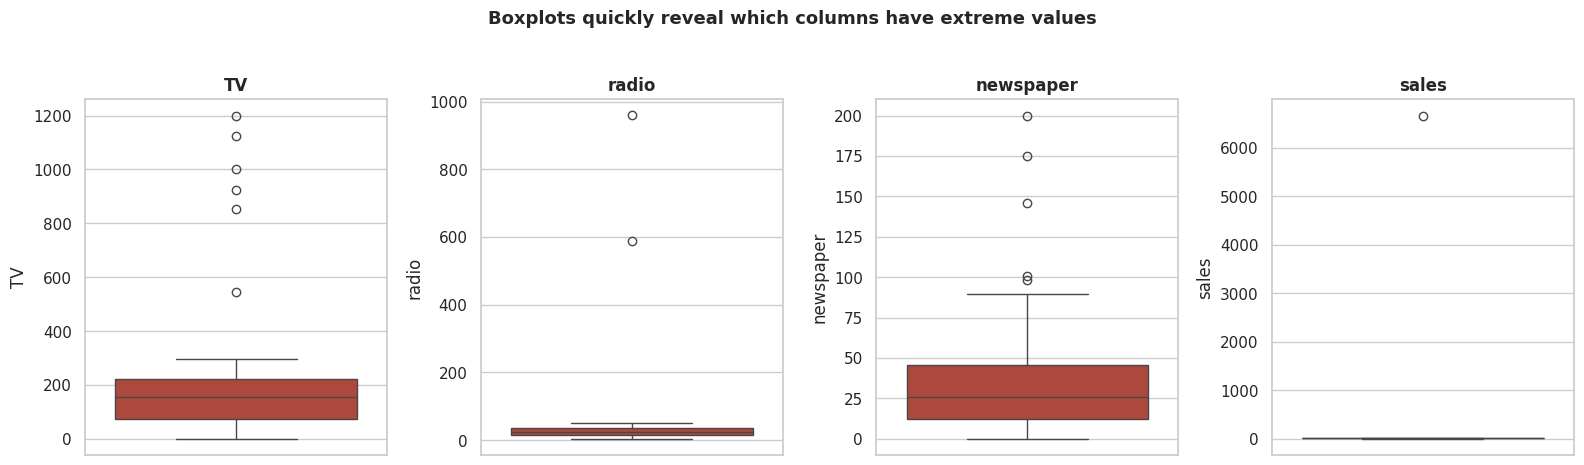

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, col in zip(axes, ['TV', 'radio', 'newspaper', 'sales']):
    sns.boxplot(y=df[col], ax=ax, color='#c0392b')
    ax.set_title(col, fontweight='bold')
plt.suptitle('Boxplots quickly reveal which columns have extreme values', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

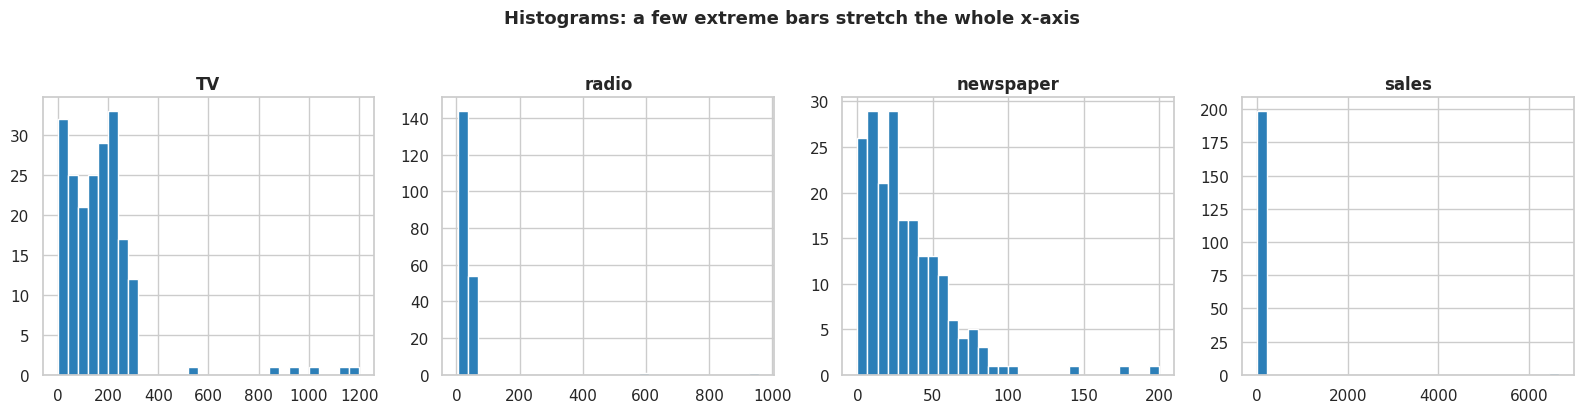

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['TV', 'radio', 'newspaper', 'sales']):
    ax.hist(df[col], bins=30, color='#2c7fb8', edgecolor='white')
    ax.set_title(col, fontweight='bold')
plt.suptitle('Histograms: a few extreme bars stretch the whole x-axis', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

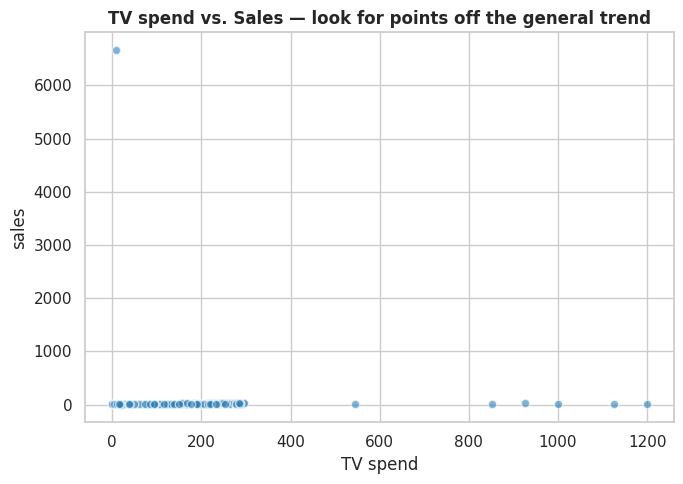

In [5]:
# Scatter is especially useful for spotting BIVARIATE outliers -- a point that's
# unremarkable on either axis alone, but clearly off the general trend combined.
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['TV'], df['sales'], alpha=0.6, color='#2c7fb8', edgecolor='white')
ax.set_xlabel('TV spend'); ax.set_ylabel('sales')
ax.set_title('TV spend vs. Sales — look for points off the general trend', fontweight='bold')
plt.tight_layout()
plt.show()

### 1b. Statistical detection — Z-score
Flags any point more than *k* standard deviations from the mean. Simple, but sensitive to the outliers themselves distorting the mean/std used to detect them (a bit of a chicken-and-egg problem).

In [6]:
from scipy import stats

z_scores = df[['TV', 'radio', 'newspaper', 'sales']].apply(stats.zscore)
z_outliers = (z_scores.abs() > 3)  # common threshold: |z| > 3

print("Outliers flagged by Z-score (|z| > 3), per column:")
print(z_outliers.sum())
df[z_outliers.any(axis=1)]

Outliers flagged by Z-score (|z| > 3), per column:
TV           5
radio        2
newspaper    3
sales        1
dtype: int64


,TV,radio,newspaper,sales
20,1200.00,27.7,53.4,18.0
29,70.60,16.0,200.0,10.5
79,1125.00,7.7,23.1,11.0
81,852.00,4.1,36.9,12.3
84,213.50,43.0,175.0,21.7
120,141.30,26.8,146.0,15.5
126,7.80,38.9,50.6,6666.0
139,925.00,43.9,1.7,20.7
162,188.40,959.0,25.6,14.9
182,1000.32,22.0,29.7,8.7


### 1c. Modified Z-score (MAD-based)
Uses the **median** and **Median Absolute Deviation (MAD)** instead of mean/std — both are far more robust to the very outliers we're trying to detect, since a handful of extreme points barely moves a median.

In [7]:
def modified_zscore(series):
    median = series.median()
    mad = (series - median).abs().median()
    # 0.6745 rescales MAD to be comparable to a standard-deviation-based z-score
    return 0.6745 * (series - median) / mad

mod_z = df[['TV', 'radio', 'newspaper', 'sales']].apply(modified_zscore)
mod_z_outliers = (mod_z.abs() > 3.5)  # common threshold for modified z-score

print("Outliers flagged by Modified Z-score (|Mz| > 3.5), per column:")
print(mod_z_outliers.sum())
print("\n(Notice this is more aggressive than plain Z-score -- MAD isn't dragged")
print(" toward the outliers the way mean/std are, so it's more sensitive to them.)")

Outliers flagged by Modified Z-score (|Mz| > 3.5), per column:
TV           5
radio        2
newspaper    3
sales        1
dtype: int64

(Notice this is more aggressive than plain Z-score -- MAD isn't dragged
 toward the outliers the way mean/std are, so it's more sensitive to them.)


### 1d. IQR method (Tukey's fences)
The classic boxplot rule: anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged.

In [8]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

iqr_outlier_mask = pd.DataFrame(index=df.index)
for col in ['TV', 'radio', 'newspaper', 'sales']:
    low, high = iqr_bounds(df[col])
    iqr_outlier_mask[col] = (df[col] < low) | (df[col] > high)
    print(f"{col:10s}: valid range [{low:8.1f}, {high:8.1f}]  ->  {iqr_outlier_mask[col].sum()} outliers")

iqr_outlier_mask['any_column'] = iqr_outlier_mask.any(axis=1)
print(f"\nRows flagged as an outlier in AT LEAST one column: {iqr_outlier_mask['any_column'].sum()}")

TV        : valid range [  -147.7,    444.4]  ->  6 outliers
radio     : valid range [   -19.2,     70.2]  ->  2 outliers
newspaper : valid range [   -37.2,     95.6]  ->  5 outliers
sales     : valid range [    -0.2,     28.0]  ->  1 outliers

Rows flagged as an outlier in AT LEAST one column: 14


### 1e. Model-based / multivariate detection
The methods above look at **one column at a time**. The techniques below look at *all* columns together, which is essential for catching a point that's only unusual in **combination** (e.g. low TV spend but very high sales — plausible for one, suspicious together).

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler

features = ['TV', 'radio', 'newspaper', 'sales']
X = df[features]
X_scaled = StandardScaler().fit_transform(X)  # distance/density-based methods need comparable scales

model_flags = pd.DataFrame(index=df.index)

# --- Isolation Forest: isolates points via random recursive splits;
#     true outliers take FEWER splits to isolate, since they sit in sparse regions.
iso = IsolationForest(contamination=0.05, random_state=42)
model_flags['Isolation Forest'] = iso.fit_predict(X_scaled) == -1

# --- Local Outlier Factor: compares a point's local density to its neighbors' --
#     good at catching outliers that are only "local" (unusual relative to their
#     neighborhood, even if not extreme on a global scale).
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
model_flags['Local Outlier Factor'] = lof.fit_predict(X_scaled) == -1

# --- DBSCAN: a clustering algorithm where points that don't belong to any dense
#     cluster are labeled -1 ("noise") -- a natural, free side-effect we can reuse
#     as an outlier flag.
dbscan = DBSCAN(eps=1.2, min_samples=5)
model_flags['DBSCAN (noise points)'] = dbscan.fit_predict(X_scaled) == -1

# --- Elliptic Envelope: fits a robust Gaussian ellipse to the "normal" bulk of the
#     data (via Mahalanobis distance) and flags anything falling outside it.
#     Assumes roughly Gaussian data -- less reliable on heavily skewed columns.
ee = EllipticEnvelope(contamination=0.05, random_state=42)
model_flags['Elliptic Envelope (Mahalanobis)'] = ee.fit_predict(X_scaled) == -1

model_flags.sum().to_frame('n_outliers_flagged')

,n_outliers_flagged
Isolation Forest,10
Local Outlier Factor,10
DBSCAN (noise points),12
Elliptic Envelope (Mahalanobis),10


In [10]:
# Do the methods agree with each other? A consensus vote is often more trustworthy
# than any single method alone.
model_flags['votes'] = model_flags.sum(axis=1)
consensus_outliers = df[model_flags['votes'] >= 3]
print(f"Rows flagged as outliers by 3+ of the 4 multivariate methods: {len(consensus_outliers)}")
consensus_outliers

Rows flagged as outliers by 3+ of the 4 multivariate methods: 10


,TV,radio,newspaper,sales
20,1200.00,27.7,53.4,18.0
29,70.60,16.0,200.0,10.5
79,1125.00,7.7,23.1,11.0
81,852.00,4.1,36.9,12.3
126,7.80,38.9,50.6,6666.0
139,925.00,43.9,1.7,20.7
162,188.40,959.0,25.6,14.9
182,1000.32,22.0,29.7,8.7
183,287.60,589.0,71.8,26.2
191,545.00,10.8,6.0,9.9


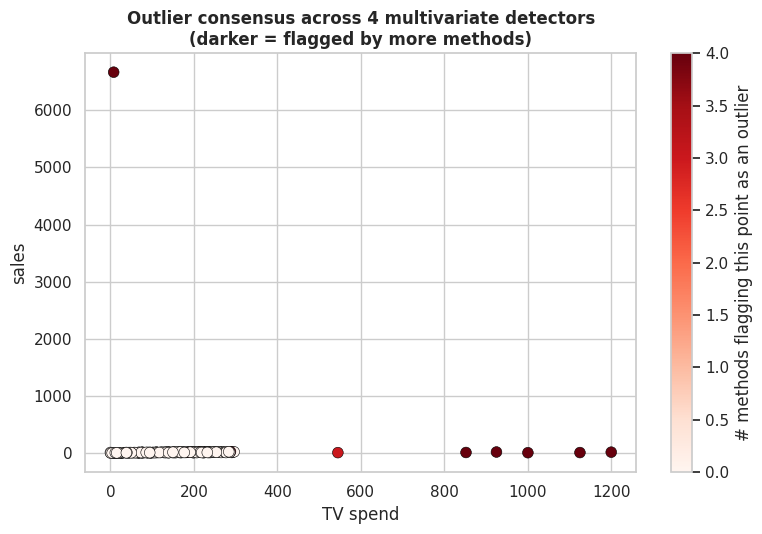

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
scatter = ax.scatter(df['TV'], df['sales'], c=model_flags['votes'], cmap='Reds',
                      s=60, edgecolor='black', linewidth=0.4)
ax.set_xlabel('TV spend'); ax.set_ylabel('sales')
ax.set_title('Outlier consensus across 4 multivariate detectors\n(darker = flagged by more methods)',
             fontweight='bold')
plt.colorbar(scatter, label='# methods flagging this point as an outlier')
plt.tight_layout()
plt.show()

## PART B — TREATMENT
Detection tells you *where* the problem is; treatment is what you actually do about it. We'll demonstrate every major treatment on the `sales` column, which has the most dramatic outliers (max 6666 vs. a median of ~13).

In [12]:
low, high = iqr_bounds(df['sales'])
print(f"IQR fence for 'sales': [{low:.1f}, {high:.1f}]")
print(f"Original sales stats -- mean: {df['sales'].mean():.1f}, median: {df['sales'].median():.1f}, "
      f"std: {df['sales'].std():.1f}, max: {df['sales'].max():.1f}")

IQR fence for 'sales': [-0.2, 28.0]
Original sales stats -- mean: 47.3, median: 12.9, std: 470.4, max: 6666.0


### 2a. Removal / trimming
The simplest treatment: just delete rows flagged as outliers. Effective, but wastes data and is a bad idea if outliers are frequent or if you need every row (e.g. small datasets, or when outliers might be genuine rare events worth keeping).

In [13]:
df_trimmed = df[(df['sales'] >= low) & (df['sales'] <= high)].copy()
print(f"Rows before trimming: {len(df)}  ->  after trimming: {len(df_trimmed)} "
      f"({len(df) - len(df_trimmed)} removed)")
print(f"New sales stats -- mean: {df_trimmed['sales'].mean():.1f}, std: {df_trimmed['sales'].std():.1f}")

Rows before trimming: 200  ->  after trimming: 199 (1 removed)
New sales stats -- mean: 14.0, std: 5.3


### 2b. Capping / Winsorization (flooring & capping)
Instead of deleting the row (and losing its `TV`/`radio`/`newspaper` values along with it), **clip** the extreme value down to the fence boundary. Keeps every row, just tames the extremity.

In [14]:
df_capped = df.copy()
df_capped['sales'] = df_capped['sales'].clip(lower=low, upper=high)
print(f"New sales stats -- mean: {df_capped['sales'].mean():.1f}, std: {df_capped['sales'].std():.1f}, "
      f"max: {df_capped['sales'].max():.1f}")

# Percentile-based capping is a common alternative to IQR fences -- e.g. cap
# anything below the 1st percentile or above the 99th percentile.
p01, p99 = df['sales'].quantile([0.01, 0.99])
df_percentile_capped = df.copy()
df_percentile_capped['sales'] = df_percentile_capped['sales'].clip(lower=p01, upper=p99)
print(f"\n1st/99th percentile fences: [{p01:.1f}, {p99:.1f}]")
print(f"Percentile-capped sales stats -- mean: {df_percentile_capped['sales'].mean():.1f}, "
      f"max: {df_percentile_capped['sales'].max():.1f}")

New sales stats -- mean: 14.1, std: 5.4, max: 28.0

1st/99th percentile fences: [3.2, 26.2]
Percentile-capped sales stats -- mean: 14.1, max: 26.2


### 2c. Transformation (log / sqrt)
Log and square-root transforms compress large values proportionally more than small ones, shrinking the *relative* influence of extreme values without deleting or altering any row's rank order.

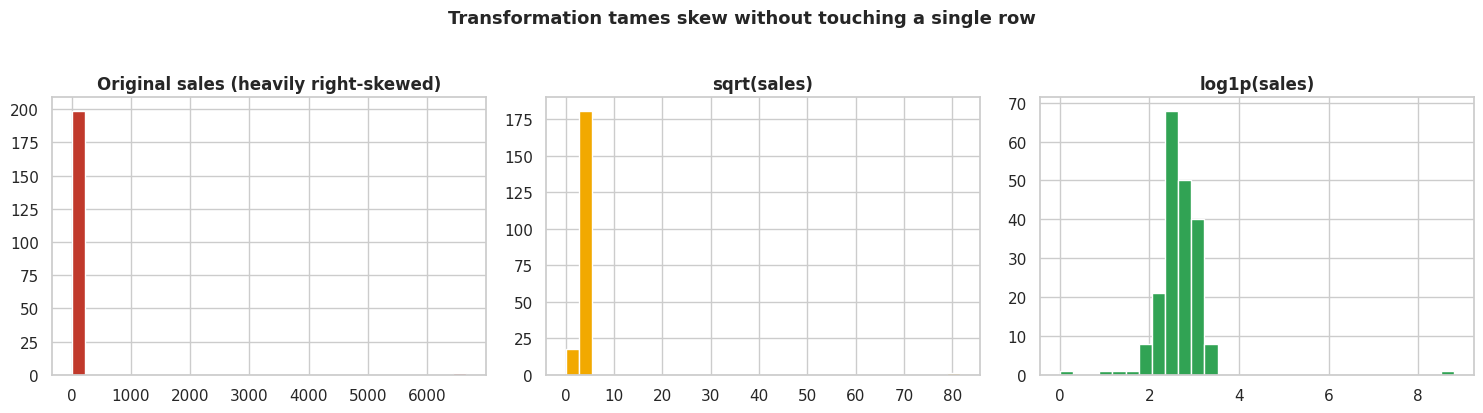

In [15]:
df_transformed = df.copy()
df_transformed['sales_log'] = np.log1p(df_transformed['sales'])   # log1p handles zero values safely
df_transformed['sales_sqrt'] = np.sqrt(df_transformed['sales'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['sales'], bins=30, color='#c0392b', edgecolor='white')
axes[0].set_title('Original sales (heavily right-skewed)', fontweight='bold')
axes[1].hist(df_transformed['sales_sqrt'], bins=30, color='#f2a900', edgecolor='white')
axes[1].set_title('sqrt(sales)', fontweight='bold')
axes[2].hist(df_transformed['sales_log'], bins=30, color='#31a354', edgecolor='white')
axes[2].set_title('log1p(sales)', fontweight='bold')
plt.suptitle('Transformation tames skew without touching a single row', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 2d. Imputation (treat outliers as missing, then fill)
A hybrid approach: mark outlier values as missing, then apply any of the imputation techniques from the missing-values notebooks (mean, median, KNN, etc.) — useful when you believe the outlier is a data-entry error rather than a genuine extreme event.

In [16]:
from sklearn.impute import SimpleImputer

df_outliers_as_missing = df.copy()
outlier_mask_sales = (df['sales'] < low) | (df['sales'] > high)
df_outliers_as_missing.loc[outlier_mask_sales, 'sales'] = np.nan
print(f"Marked {outlier_mask_sales.sum()} outlier values as missing.")

df_outliers_as_missing['sales'] = SimpleImputer(strategy='median').fit_transform(
    df_outliers_as_missing[['sales']])
print(f"After median-imputing the (former) outliers -- mean: {df_outliers_as_missing['sales'].mean():.1f}, "
      f"max: {df_outliers_as_missing['sales'].max():.1f}")

Marked 1 outlier values as missing.
After median-imputing the (former) outliers -- mean: 14.0, max: 27.0


## 3. Comparing every treatment side-by-side

In [17]:
treatment_summary = pd.DataFrame({
    'Original': df['sales'],
    'Trimmed (removed rows)': df_trimmed['sales'].reindex(df.index),
    'Capped (IQR fence)': df_capped['sales'],
    'Capped (1st/99th pct)': df_percentile_capped['sales'],
    'Log-transformed': df_transformed['sales_log'],
    'Outlier -> median-imputed': df_outliers_as_missing['sales'],
}).describe().T[['mean', 'std', 'min', 'max']].round(2)
treatment_summary

,mean,std,min,max
Original,47.28,470.40,0.00,6666.00
Trimmed (removed rows),14.02,5.28,0.00,27.00
Capped (IQR fence),14.09,5.36,0.00,28.02
Capped (1st/99th pct),14.10,5.27,3.18,26.21
Log-transformed,2.67,0.60,0.00,8.80
Outlier -> median-imputed,14.02,5.27,0.00,27.00


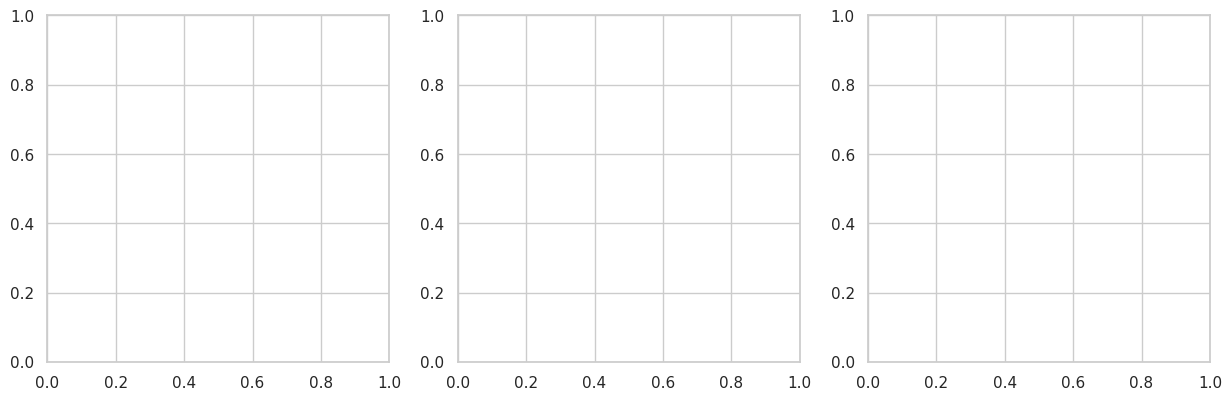

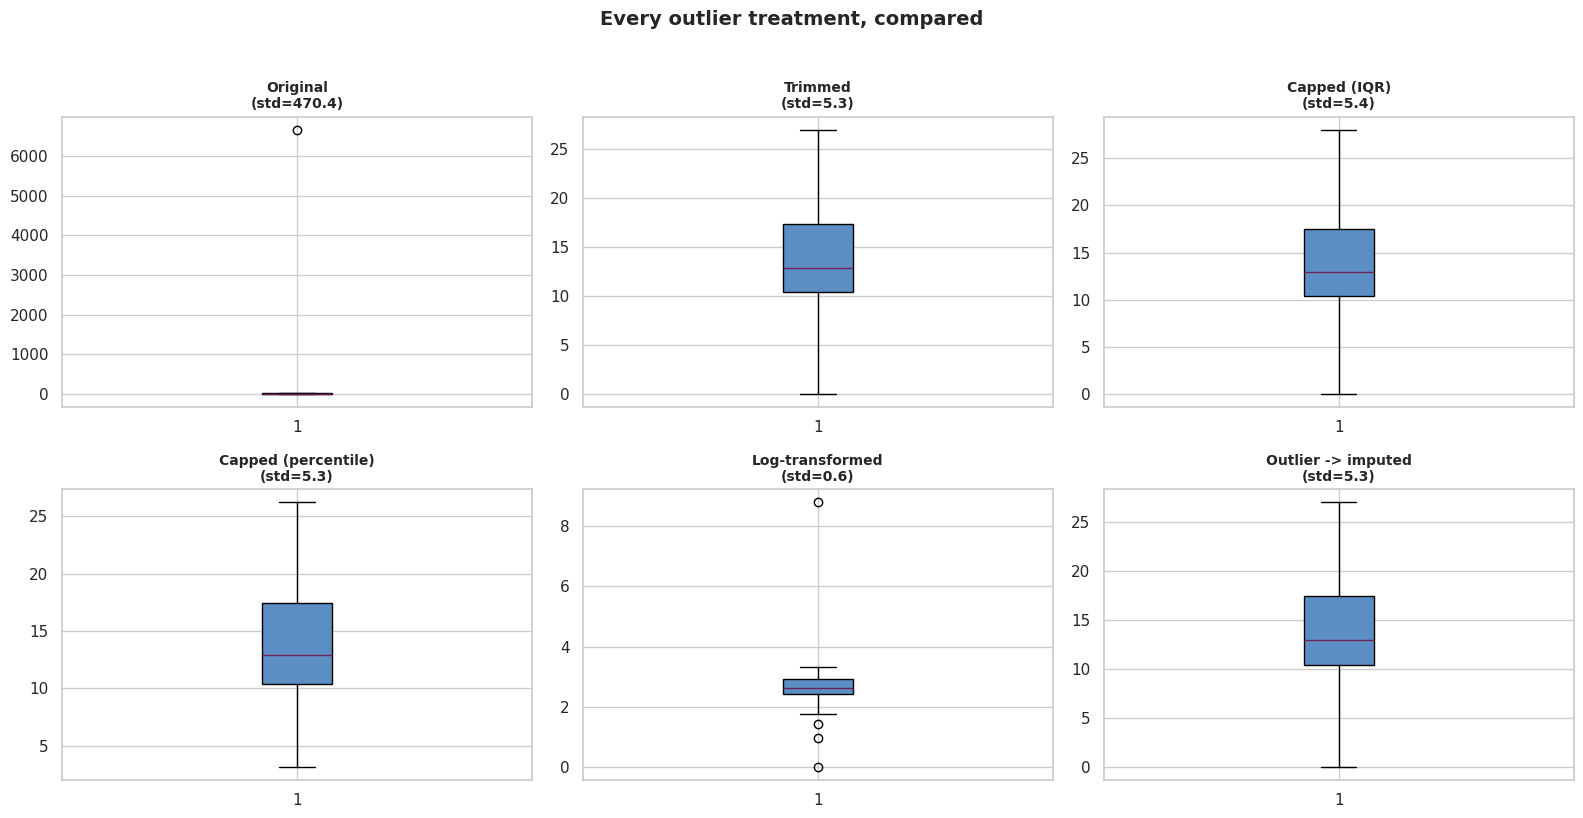

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title in zip(
    axes,
    ['Original', 'sales', 'sales'],  # placeholder, replaced below
    ['', '', '']
):
    pass  # cleared -- see explicit plot below

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
plots = [
    ('Original', df['sales']),
    ('Trimmed', df_trimmed['sales']),
    ('Capped (IQR)', df_capped['sales']),
    ('Capped (percentile)', df_percentile_capped['sales']),
    ('Log-transformed', df_transformed['sales_log']),
    ('Outlier -> imputed', df_outliers_as_missing['sales']),
]
for ax, (title, series) in zip(axes, plots):
    ax.boxplot(series.dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#5b8ec4'))
    ax.set_title(f"{title}\n(std={series.std():.1f})", fontweight='bold', fontsize=10)
plt.suptitle('Every outlier treatment, compared', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Key takeaways

**Detection:**

| Method | Type | Best for |
|---|---|---|
| Boxplot / histogram / scatter | Visual | Quick first look, always do this first |
| Z-score | Statistical, univariate | Roughly normal data, no extreme skew |
| Modified Z-score (MAD) | Statistical, univariate | Skewed data, or when you don't trust mean/std |
| IQR (Tukey's fences) | Statistical, univariate | The classic, robust, distribution-free default |
| Isolation Forest | Model-based, multivariate | Large datasets, no assumption about data shape |
| Local Outlier Factor | Model-based, multivariate | Local/contextual outliers, varying density regions |
| DBSCAN | Model-based, multivariate (via clustering) | When you also want a natural clustering, not just an outlier flag |
| Elliptic Envelope | Model-based, multivariate | Roughly Gaussian multivariate data |

**Treatment:**

| Method | Keeps all rows? | Best for |
|---|---|---|
| Removal / trimming | No | Outliers are rare, clearly erroneous, and you have data to spare |
| Capping / winsorization | Yes | You want to keep every row's other columns intact |
| Transformation (log/sqrt) | Yes | Whole-column skew, not just a handful of points |
| Imputation | Yes | You believe the outlier is a data-entry error, not a real value |

**No single method is universally "correct."** Always look at *why* a value is extreme before choosing a treatment — a genuine record of an unusually successful campaign is very different from a typo that added an extra zero.

---
## Decision guide — detect, then decide

**Step 1 — detect.** Use IQR unless you have a reason not to. It's based on quartiles, so unlike the z-score
it isn't distorted by the very outliers it's looking for.

| Method | Use when | Weakness |
|---|---|---|
| **Boxplot / histogram** | always, first | eyeballing isn't a criterion you can defend |
| **IQR (1.5 × spread)** | the default choice | assumes one column at a time |
| **Z-score (\|z\| > 3)** | data is roughly normal | the outlier inflates the SD it's measured against |
| **Modified z-score (MAD)** | small samples, skewed data | less familiar to a general reader |
| **Isolation Forest / Mahalanobis** | odd *combinations* across columns | harder to explain in one line |

**Step 2 — decide.** Ask one question: *is this value wrong, or is it real and rare?*

| Situation | Treatment | Justification to write |
|---|---|---|
| Clearly impossible (age 600, negative price) | **remove** the row | "Physically impossible, therefore a data-entry error." |
| Real but extreme, and you need every row | **cap** at the IQR fence | "Retains the record while limiting its leverage on the mean." |
| Whole column is right-skewed (income, spend) | **log transform** | "Compresses the tail; the extremes become ordinary values rather than outliers." |
| Extreme and you don't trust it, but the row matters | treat as **missing**, then impute | "The other fields in the row are still usable." |
| The outlier *is* the phenomenon (fraud, churn) | **keep and flag it** | "Removing it would delete the signal being studied." |

**Never** remove outliers just because they hurt your R². Say what you did, how many rows it affected, and why.

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Quartiles | `s.quantile(0.25)`, `s.quantile(0.75)` |
| IQR | `Q3 - Q1` |
| IQR fences | `Q1 - 1.5*IQR`, `Q3 + 1.5*IQR` |
| Flag outliers | `(s < low) | (s > high)` |
| Count them | `mask.sum()` |
| Z-score | `(s - s.mean()) / s.std()` |
| Z-score, scipy | `np.abs(stats.zscore(s)) > 3` |
| Modified z (MAD) | `0.6745*(s-med)/MAD` |
| Remove | `df[(s >= low) & (s <= high)]` |
| Cap / winsorise | `s.clip(lower=low, upper=high)` |
| Log transform | `np.log1p(s)` |
| Boxplot | `df.boxplot(column=['a','b'])` |
| Multivariate | `IsolationForest().fit_predict(X) == -1` |

### Adapting this in the exam

- 'Detect and treat the outliers' → detect with IQR, show the count, choose a treatment, justify it, show the before/after.
- Asked for the z-score method specifically? Use it, but add one line noting the IQR method is more robust.
- Asked to 'handle' rather than 'remove'? That's an invitation to cap or transform, not to delete.

### Traps that cost marks

- The z-score method is weakened by the outlier itself — one huge value inflates the standard deviation and hides itself. IQR doesn't have this problem.
- `np.log()` fails on zero or negative values. Use `np.log1p()` (log of 1+x) instead.
- Capping changes your data. Report how many values you moved and by how much.
- Applying IQR to a categorical column that happens to be stored as numbers (postcodes, IDs) is meaningless.
- A boxplot's whiskers *are* the 1.5×IQR rule — the dots beyond them are exactly what `.clip()` would move.
- Removing outliers before a train/test split leaks information. Do it inside the training fold only.